In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from tabulate import tabulate
from astropy.time import Time
from tqdm import tqdm
import csv
import os
import glob
import multiprocessing
from matplotlib.patches import Patch
from scipy.stats import kurtosis, skew

In [4]:
import glob
import pandas as pd

# Initial hit count (absolute path)
print('initial hit count')
for file in glob.glob('/datax/scratch/ellambishop/test_refine/*.pkl'):
    df = pd.read_pickle(file)
    print(f"{file}: {len(df)} rows")

# Cleaned hit count (relative path from current directory)
print('\ncleaned hit count')
for file in glob.glob('clean_data/*.pkl'):
    df = pd.read_pickle(file)
    print(f"{file}: {len(df)} rows")



initial hit count
/datax/scratch/ellambishop/test_refine/vlass_incoherent.pkl: 77431 rows
/datax/scratch/ellambishop/test_refine/vlass_phase_center.pkl: 1426 rows
/datax/scratch/ellambishop/test_refine/vlass_other.pkl: 420344 rows
/datax/scratch/ellambishop/test_refine/non_vlass_incoherent.pkl: 1342625 rows
/datax/scratch/ellambishop/test_refine/non_vlass_phase_center.pkl: 845960 rows
/datax/scratch/ellambishop/test_refine/non_vlass_other.pkl: 1942776 rows

cleaned hit count


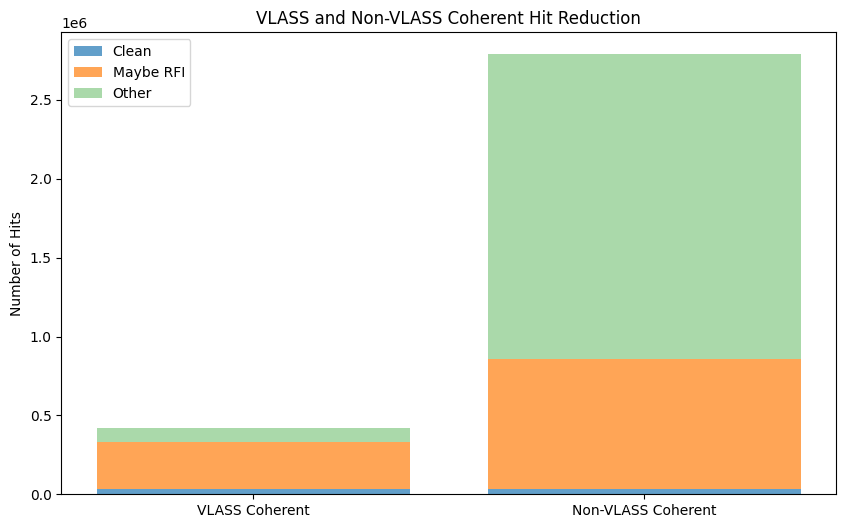

In [5]:
import matplotlib.pyplot as plt

# Categories
categories = ["VLASS Coherent", "Non-VLASS Coherent"]

# Initial counts
initial = [1426+420344, 845960+1942776, ]  # total hits

# Cleaned counts (clean + unmatched clean)
clean = [110+36261, 592+33869]  # sum of clean + clean unmatched

# Maybe RFI counts (maybe_rfi + unmatched maybe)
maybe_rfi = [40092+252700, 667374+157555]

# Other 
other = [initial[0] - (clean[0] + maybe_rfi[0]),
         initial[1] - (clean[1] + maybe_rfi[1])]

# Plot stacked bar
plt.figure(figsize=(10,6))
plt.bar(categories, clean, label='Clean', alpha=0.7)
plt.bar(categories, maybe_rfi, bottom=clean, label='Maybe RFI', alpha=0.7)
plt.bar(categories, other, bottom=[c+m for c,m in zip(clean, maybe_rfi)],
        label='Other', alpha=0.4)
plt.ylabel("Number of Hits")
plt.title("VLASS and Non-VLASS Coherent Hit Reduction")
plt.legend()
plt.show()


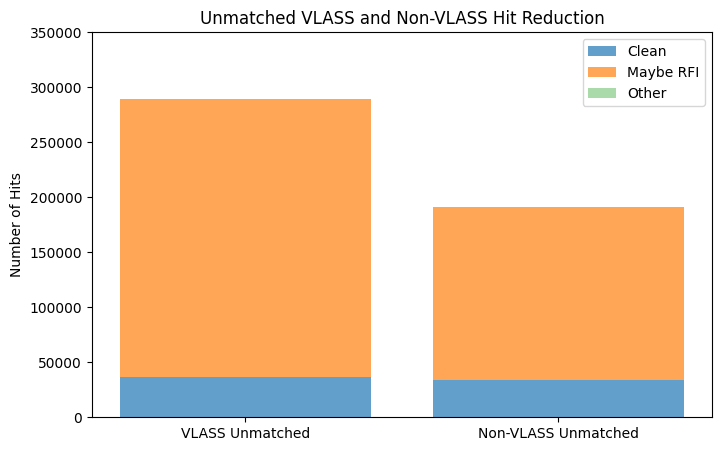

In [6]:
# 3️⃣ Unmatched
categories = ["VLASS Unmatched", "Non-VLASS Unmatched"]

# Initial counts for unmatched only
initial = [36261 + 252700, 33869 + 157555]

# Cleaned counts (only unmatched clean)
clean = [36261, 33869]

# Maybe RFI counts (only unmatched maybe_rfi)
maybe_rfi = [252700, 157555]

# Other (remaining hits not accounted in clean or maybe)
other = [initial[0] - (clean[0] + maybe_rfi[0]),
         initial[1] - (clean[1] + maybe_rfi[1])]

plt.figure(figsize=(8,5))
plt.bar(categories, clean, label='Clean', alpha=0.7)
plt.bar(categories, maybe_rfi, bottom=clean, label='Maybe RFI', alpha=0.7)
plt.bar(categories, other, bottom=[c+m for c,m in zip(clean, maybe_rfi)],
        label='Other', alpha=0.4)
plt.ylabel("Number of Hits")
plt.title("Unmatched VLASS and Non-VLASS Hit Reduction")
plt.ylim(0,350000)
plt.legend()
plt.savefig('unmatched_coh.jpg')